In [20]:
import numpy as np 
import xarray as xr
from pathlib import Path 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec
import sys

DIR = "/Users/knv2/Documents/codebase/AFL-tutorial/3DPhaseDiagram"
folders = [DIR+"/modules/", DIR+ "/dataset/", DIR+"/benchmarking/v2.0/"]
for path in folders:
    if path not in sys.path:
        sys.path.append(path)
from helpers import plot_progress, plot_sampling

In [21]:
RESULTS_DIR = "./results/"

### P1 : Sample a composition and temperature combination from a 3D space

In [22]:
def get_immediate_subdirs(path):
    return [str(p) for p in Path(path).iterdir() if p.is_dir()]
def get_sorted_nc_files(path):
    files = [p for p in Path(path).iterdir() if p.is_file() and p.suffix == ".nc"]
    # sort by the integer after 'ds_' and before '.nc'
    files.sort(key=lambda p: int(p.stem.split("_")[1]))
    return [str(f) for f in files]

In [23]:
def plot_progress_p1(ds, 
                  design_space_variable="design_space", 
                  grid_variable="design_space_grid", 
                  design_space_dim="ds_dim", 
                  composition_variables=["protein", "glycerol"],
                  temperature_variable="temperature",
                  labels_variable="phases",
                  phase_probability_variable="phase_entropy",
                  ):
    """Plot cost and entropy in 3D."""
    fig = plt.figure(figsize=(4*3, 4))
    gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=1e-5)

    ax_sampling = fig.add_subplot(gs[0, 0], projection="3d")
    x = ds[design_space_variable].sel({design_space_dim:composition_variables[0]}).values
    y = ds[design_space_variable].sel({design_space_dim:composition_variables[1]}).values
    z = ds[design_space_variable].sel({design_space_dim:temperature_variable}).values
    ax_sampling.scatter(x, y, z, c=ds[labels_variable].values)

    xg = ds[grid_variable].sel({design_space_dim:composition_variables[0]}).values
    yg = ds[grid_variable].sel({design_space_dim:composition_variables[1]}).values
    zg = ds[grid_variable].sel({design_space_dim:temperature_variable}).values    

    norm = mcolors.Normalize(vmin=0, vmax=1.0)
    cmap = plt.get_cmap("coolwarm")
    ax_entropy = fig.add_subplot(gs[0, 1], projection="3d")
    mappable = ax_entropy.scatter(xg, yg, zg,
        c=ds[phase_probability_variable].values,
        cmap=cmap,
        norm = norm,
        s=20
    )
    cax = fig.add_subplot(gs[0, 2])
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label(phase_probability_variable)

    for ax in [ax_sampling, ax_entropy]:
        ax.set_xlabel(composition_variables[0])
        ax.set_ylabel(composition_variables[1])
        ax.set_zlabel(temperature_variable, labelpad=1)
        ax.set_xlim(0, 80)
        ax.set_ylim(0, 12)
        ax.set_zlim(0, 50)
    
    # Shrink extra white space manually
    ax_sampling.set_position([0.05, 0.1, 0.4, 0.8])  # [left, bottom, width, height]
    ax_entropy.set_position([0.4, 0.1, 0.4, 0.8])
    cax.set_position([0.8, 0.25, 0.01, 0.5])
    
    return fig, [ax_sampling, ax_entropy, cax] 

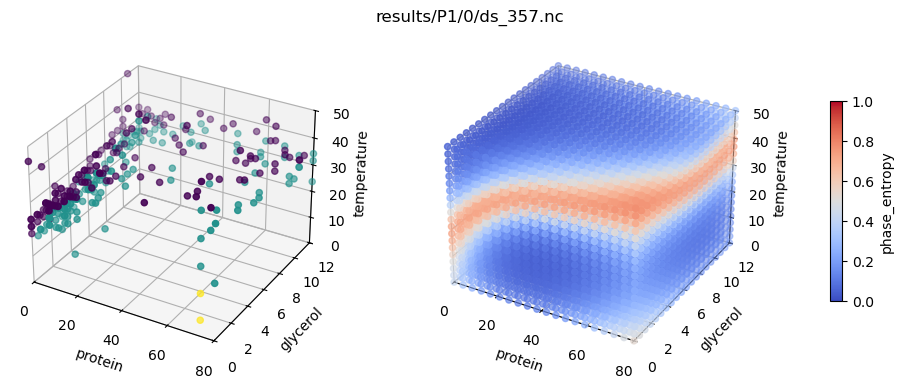

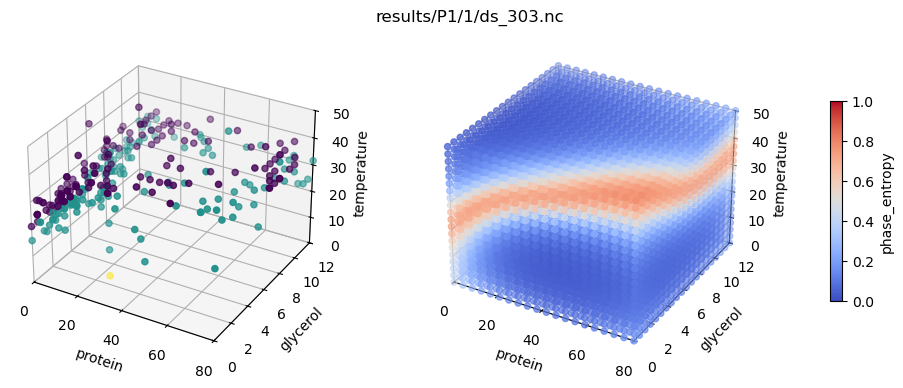

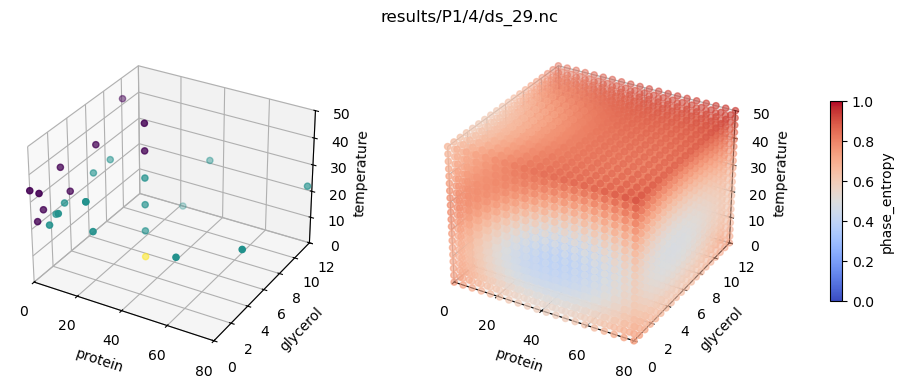

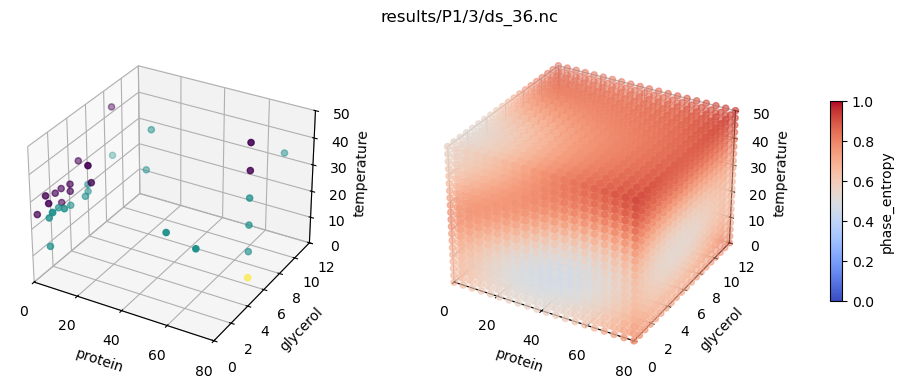

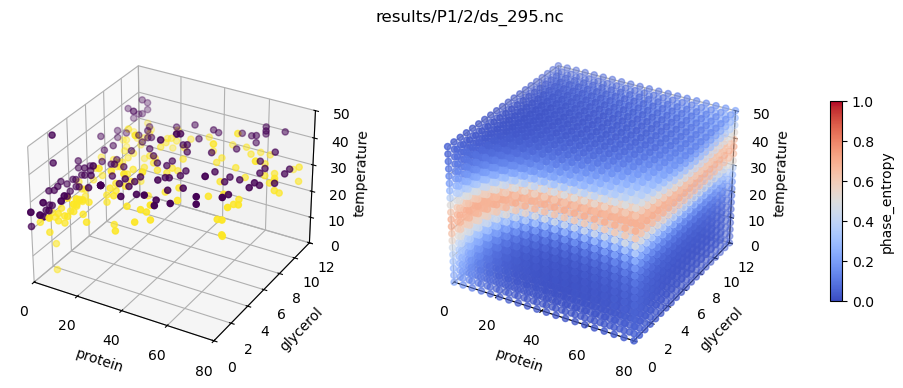

In [24]:
pipeline_direc = RESULTS_DIR + "/P1/"
run_direcs = get_immediate_subdirs(pipeline_direc)
for direc in run_direcs:
    ds_files = get_sorted_nc_files(direc)
    ds = xr.load_dataset(ds_files[-1])
    fig, axs = plot_progress_p1(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
    )
    fig.suptitle(ds_files[-1])
    plt.show()

## P2 : Single composition and temperature with feasibility scaled acquisition

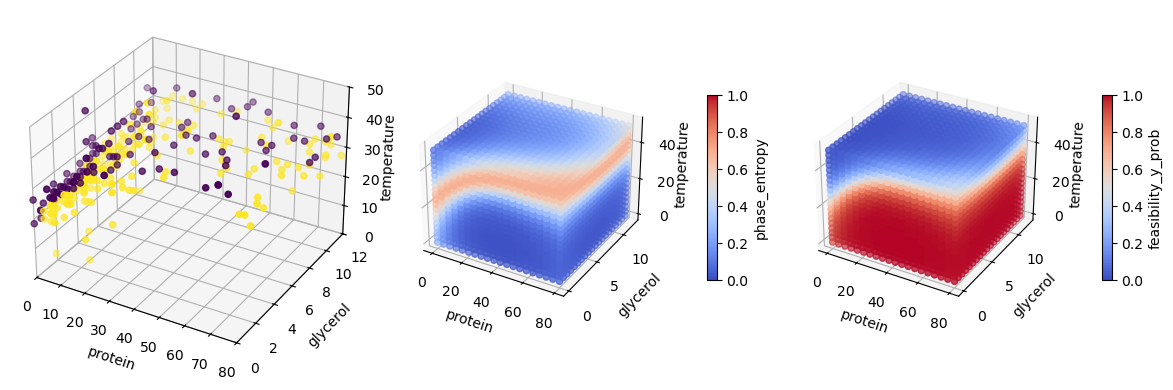

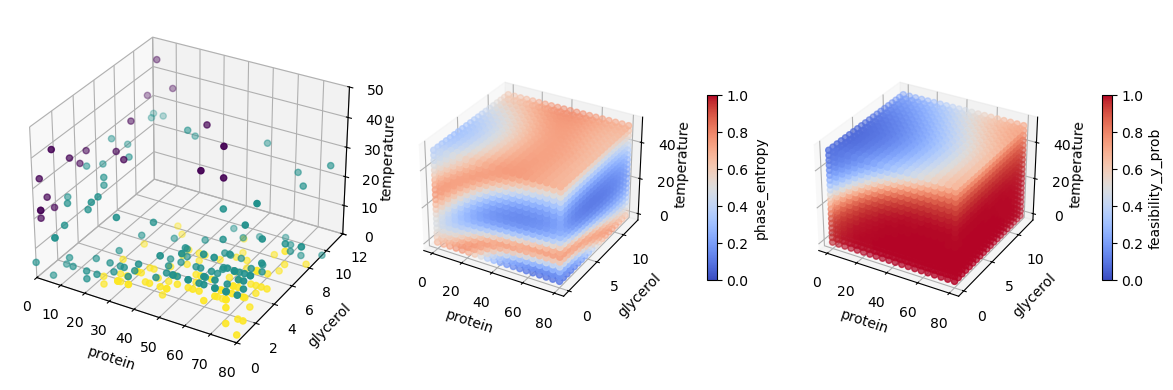

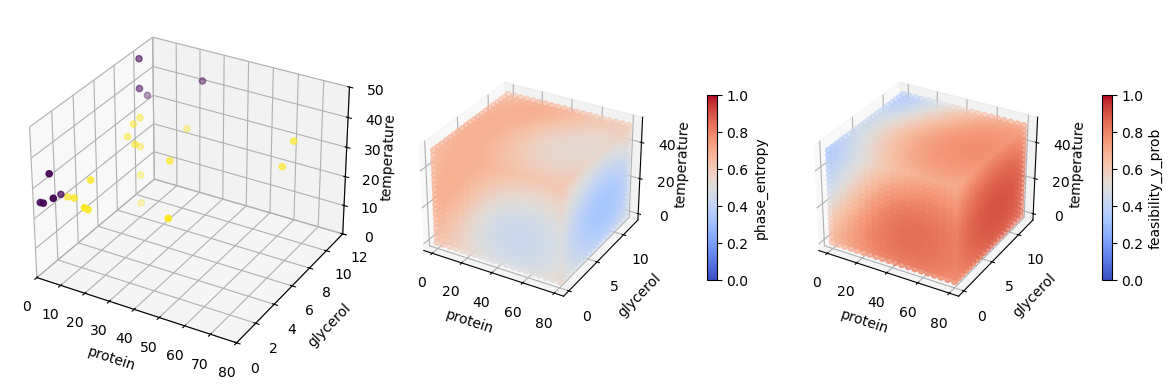

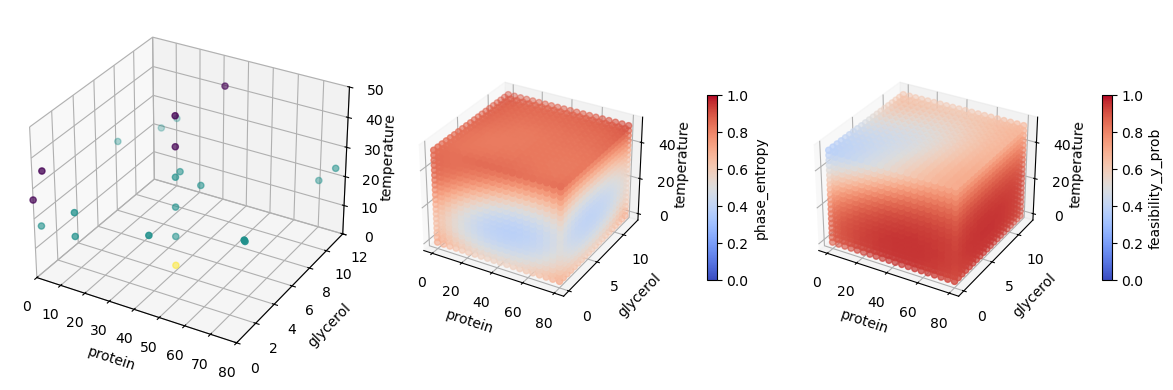

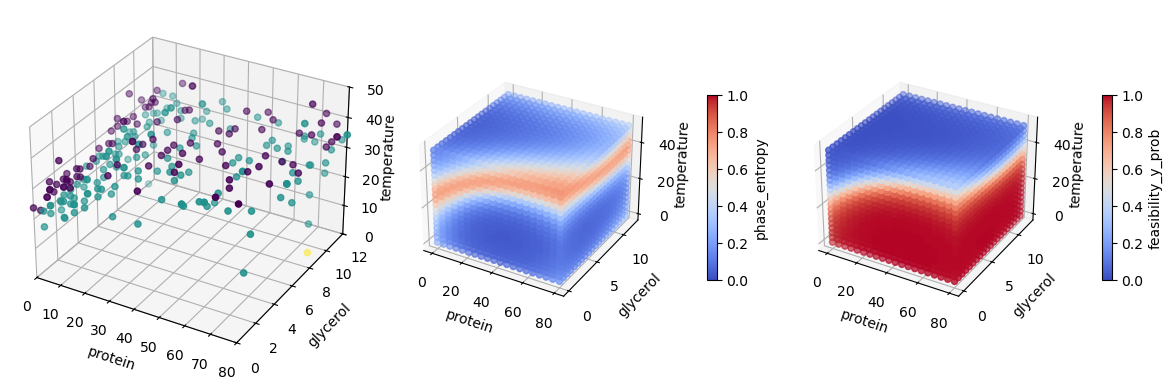

In [25]:
pipeline_direc = RESULTS_DIR + "/P2/"
run_direcs = get_immediate_subdirs(pipeline_direc)
for direc in run_direcs:
    ds_files = get_sorted_nc_files(direc)
    ds = xr.load_dataset(ds_files[-1])
    plot_progress(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
        feasibilty_probability_variable="feasibility_y_prob"
    )
    plt.show()

## P3 : Single composition and batch temperature based on FWHM near phase boundaries

In [26]:
pipeline_direc = RESULTS_DIR + "/P3/"
run_direcs = get_immediate_subdirs(pipeline_direc)

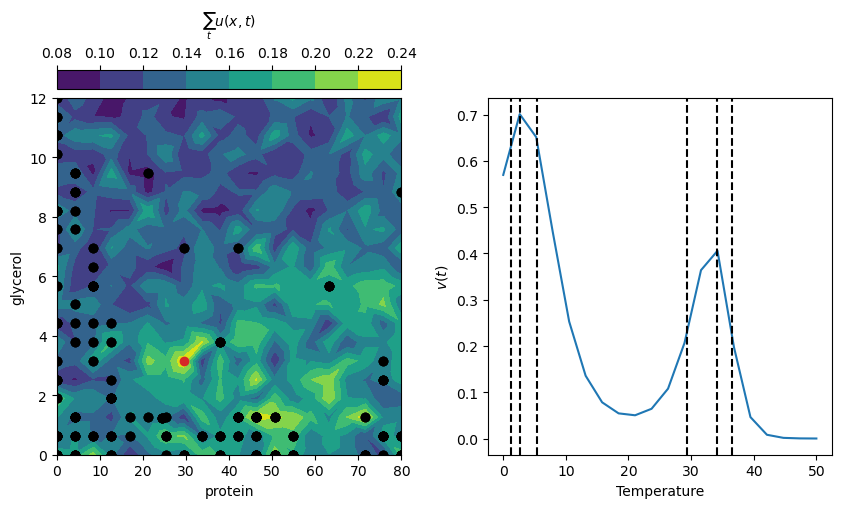

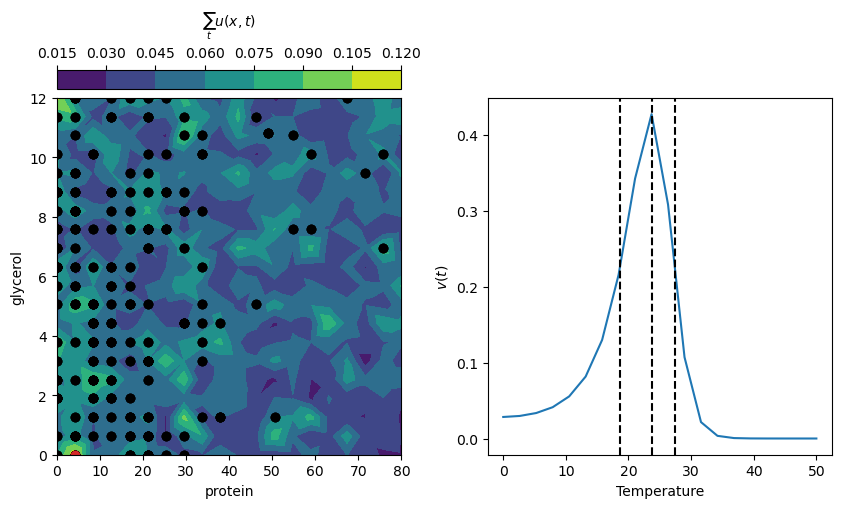

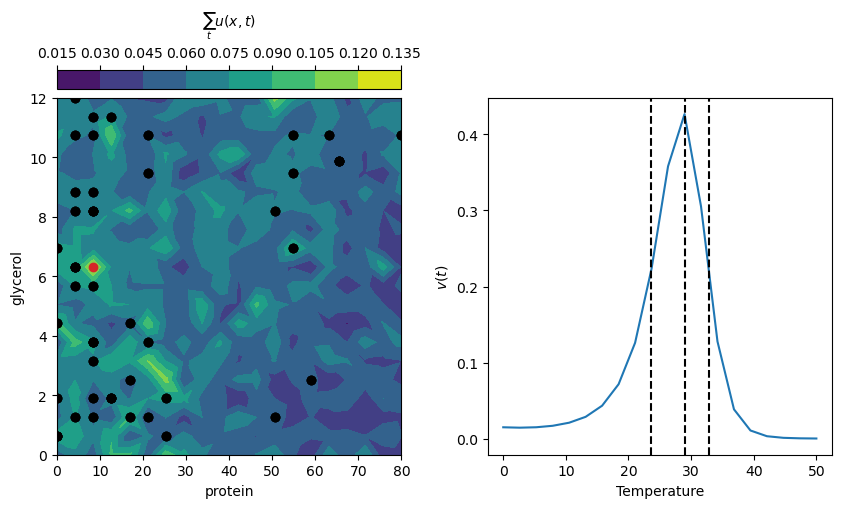

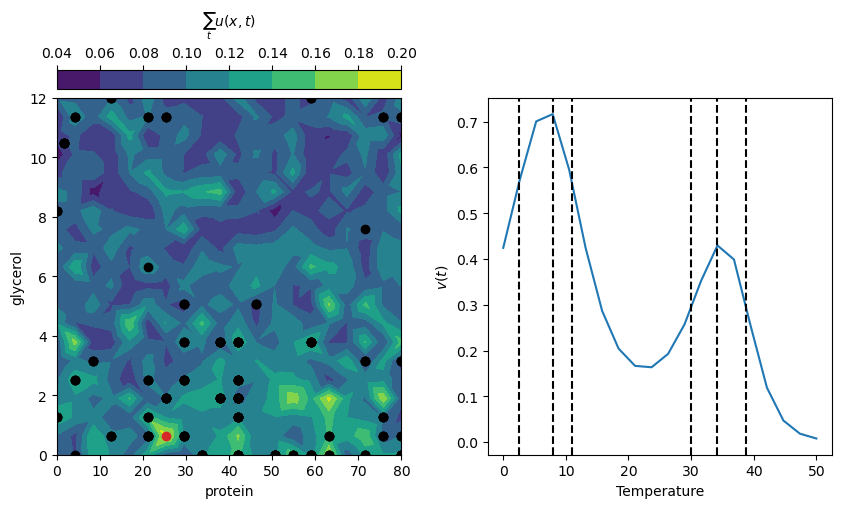

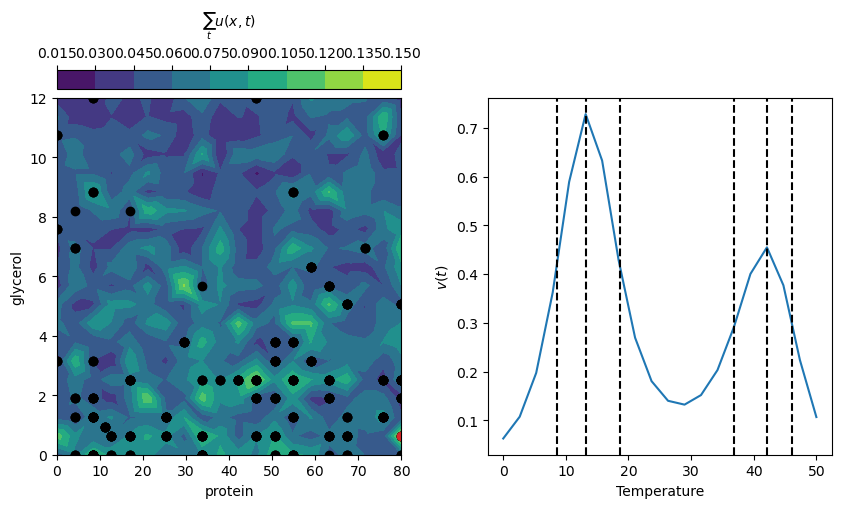

In [27]:
for direc in run_direcs:
    ds_files = get_sorted_nc_files(direc)
    ds = xr.load_dataset(ds_files[-1])
    plot_sampling(
        ds,
        "design_space",
        "ds_dim",
        "protein_glycerol_domain",
        "composition_utility_with_cost",
        "composition_next",
        "temperature_domain",
        "temperature_utility_with_cost",
        "temperature_next"
    )
    plt.show()
    ds

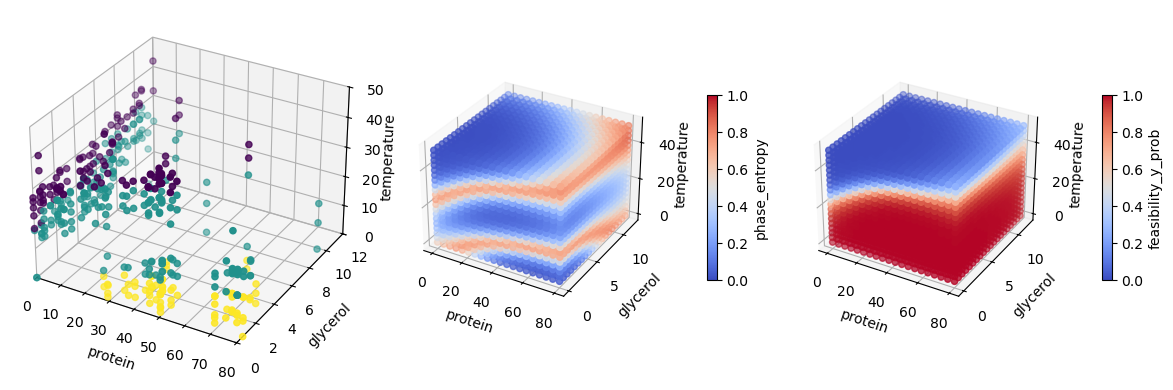

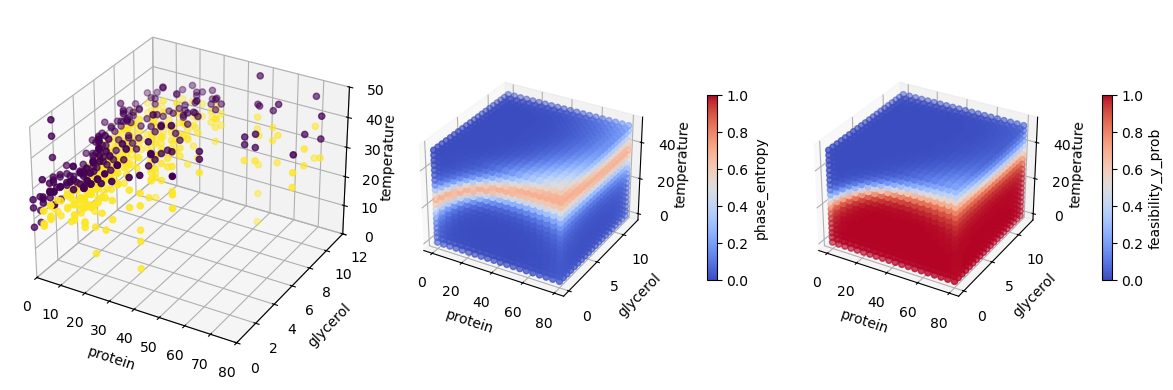

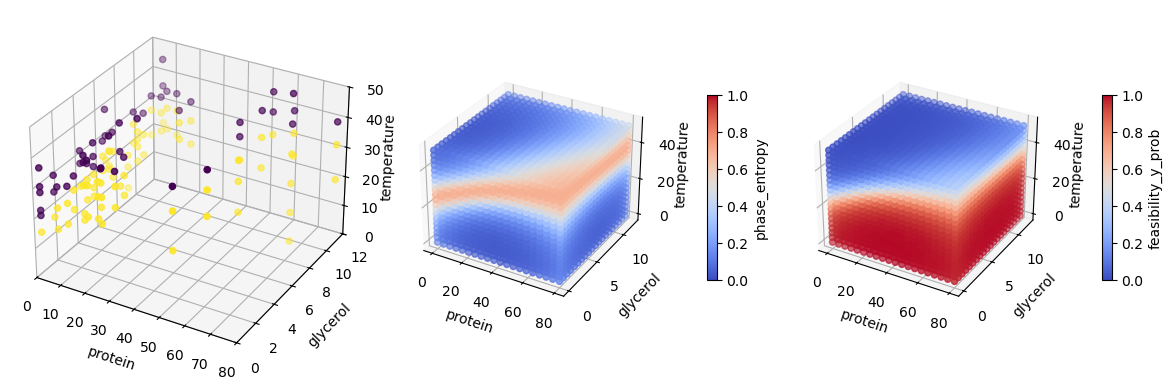

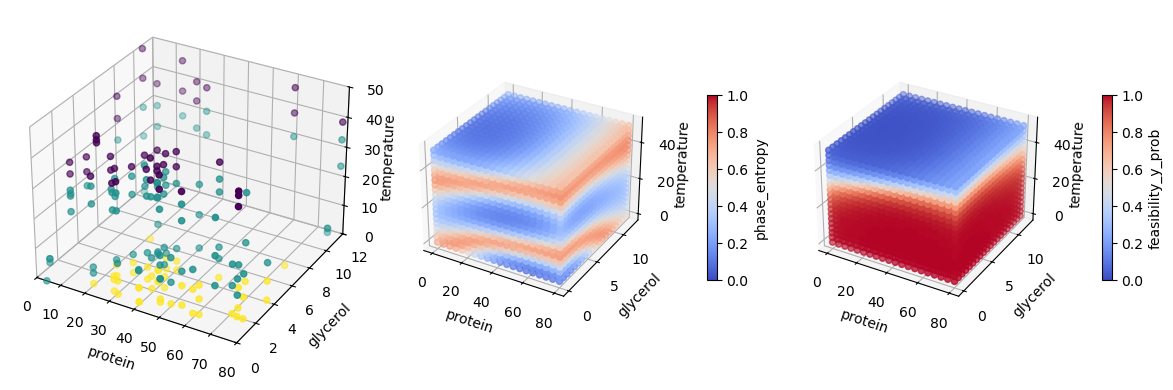

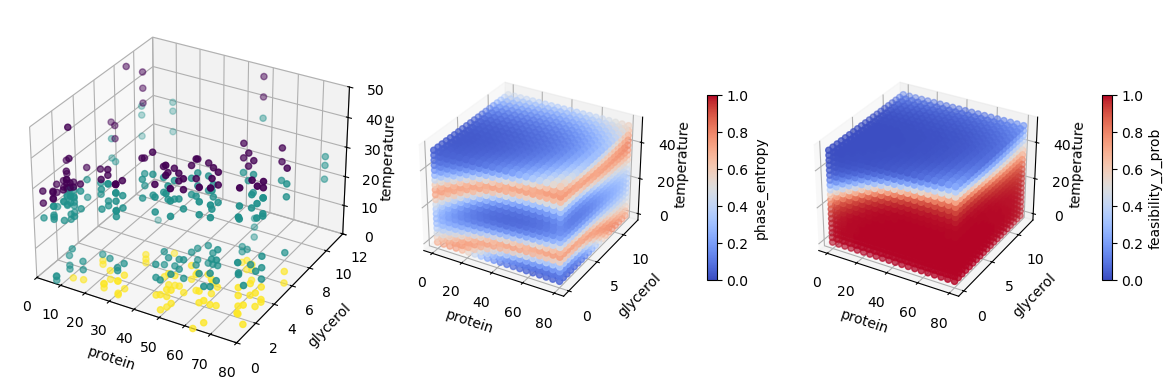

In [28]:
for direc in run_direcs:
    ds_files = get_sorted_nc_files(direc)
    ds = xr.load_dataset(ds_files[-1])
    plot_progress(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
        feasibilty_probability_variable="feasibility_y_prob"
    )
    plt.show()

## P4: Single composition with batch of times adaptively selected through acquisition optimization

In [29]:
pipeline_direc = RESULTS_DIR + "/P4/"
run_direcs = get_immediate_subdirs(pipeline_direc)

In [30]:
for direc in run_direcs:
    ds_files = get_sorted_nc_files(direc)
    ds = xr.load_dataset(ds_files[-1])
    plot_sampling(
        ds,
        "design_space",
        "ds_dim",
        "protein_glycerol_domain",
        "composition_utility_with_cost",
        "composition_next",
        "temperature_domain",
        "temperature_utility_with_cost",
        "temperature_next"
    )
    plt.show()

IndexError: list index out of range

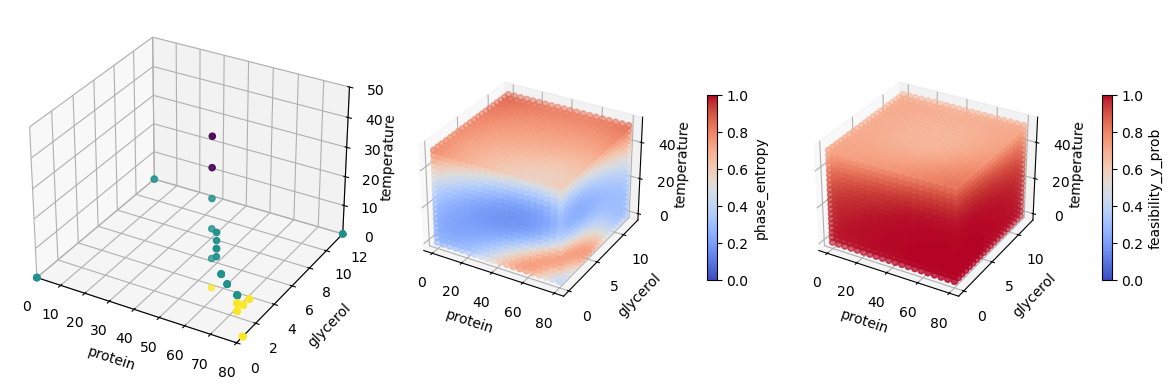

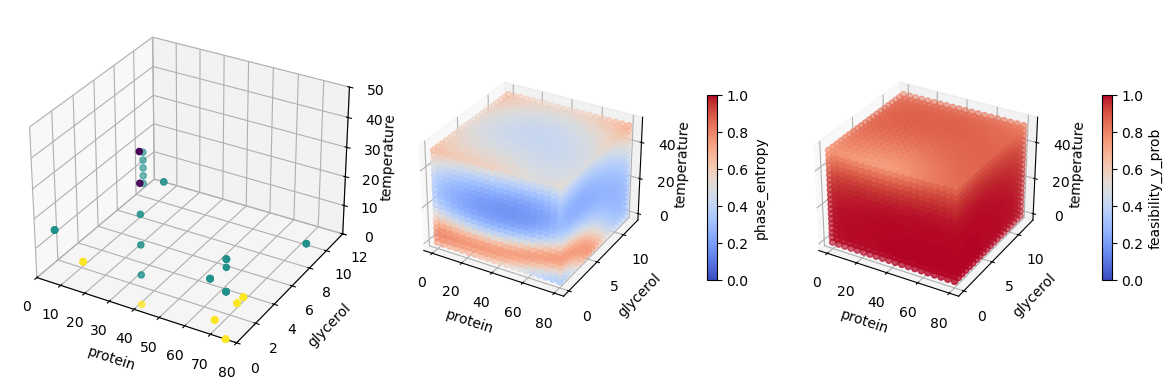

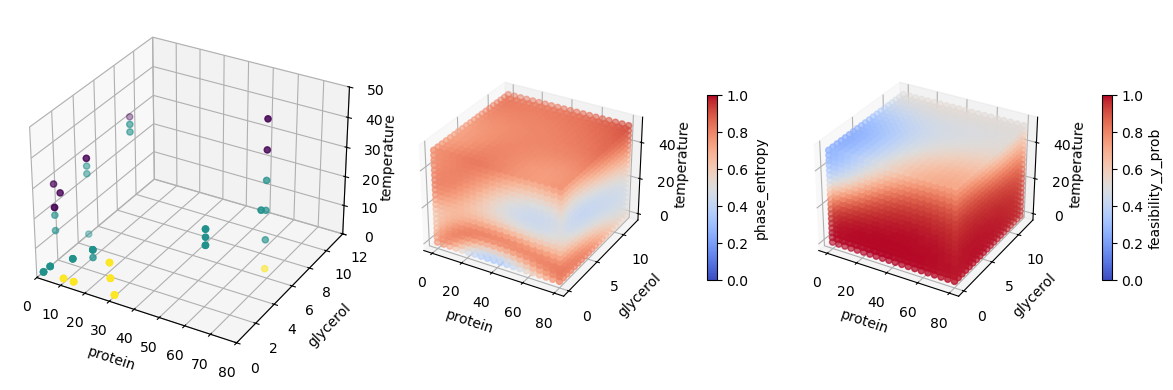

In [ ]:
for direc in run_direcs:
    ds_files = get_sorted_nc_files(direc)
    ds = xr.load_dataset(ds_files[-1])
    plot_progress(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
        feasibilty_probability_variable="feasibility_y_prob"
    )
    plt.show()

## P5: Single composition with temperatures sampled linearly between the feasible region

In [31]:
pipeline_direc = RESULTS_DIR + "/P5/"
run_direcs = get_immediate_subdirs(pipeline_direc)

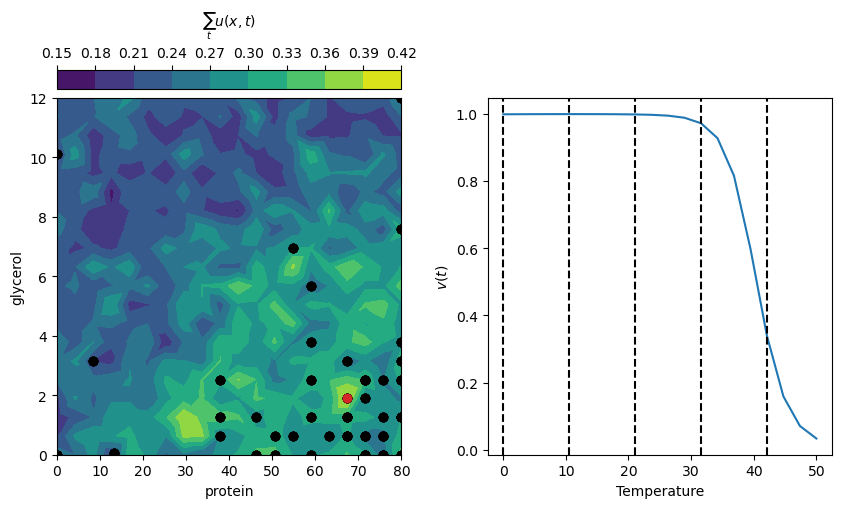

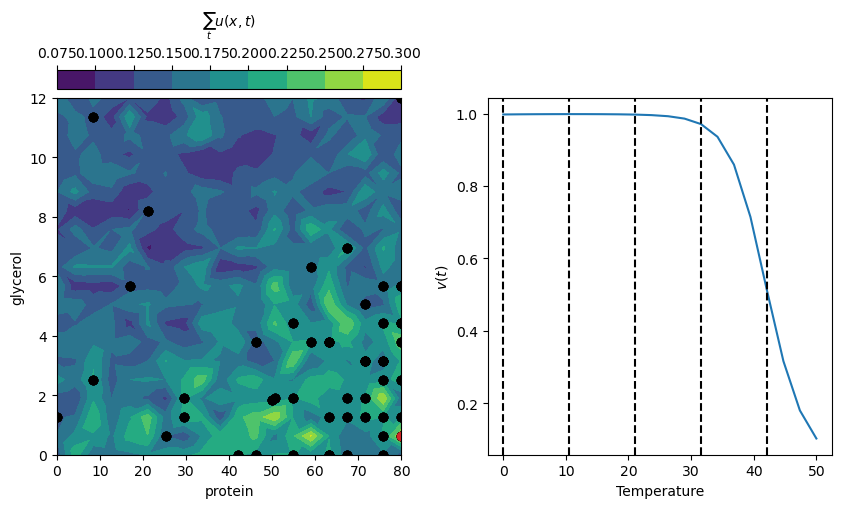

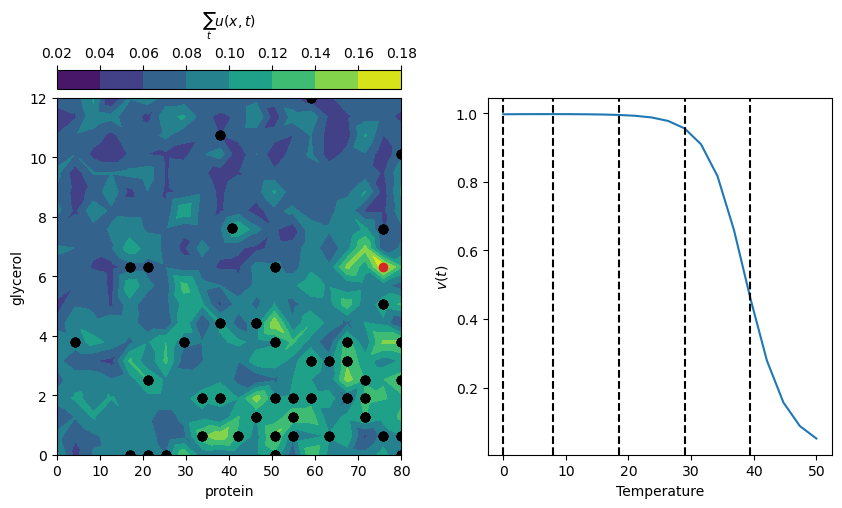

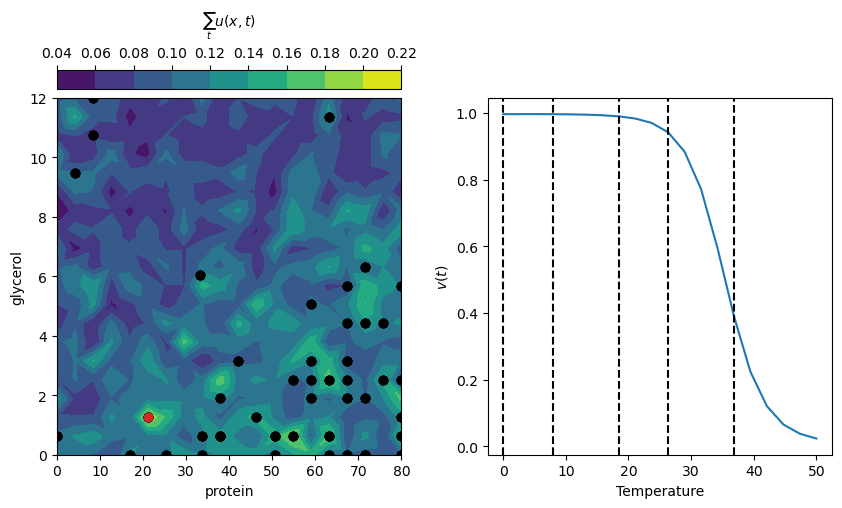

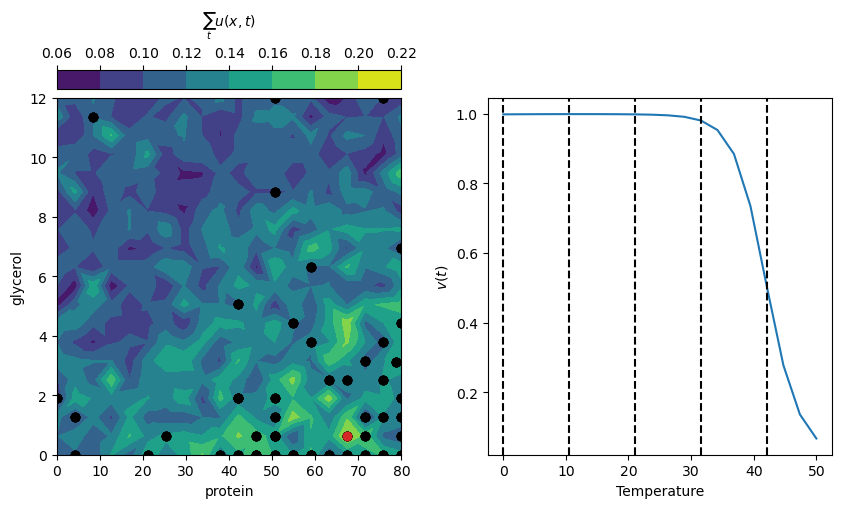

In [32]:
for direc in run_direcs:
    ds_files = get_sorted_nc_files(direc)
    ds = xr.load_dataset(ds_files[-1])
    plot_sampling(
        ds,
        "design_space",
        "ds_dim",
        "protein_glycerol_domain",
        "composition_utility_with_cost",
        "composition_next",
        "temperature_domain",
        "temperature_utility",
        "temperature_next"
    )
    plt.show()

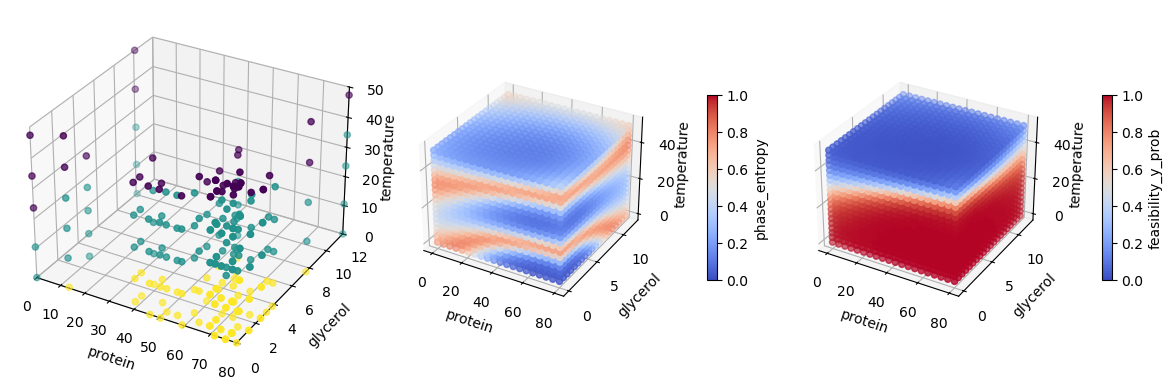

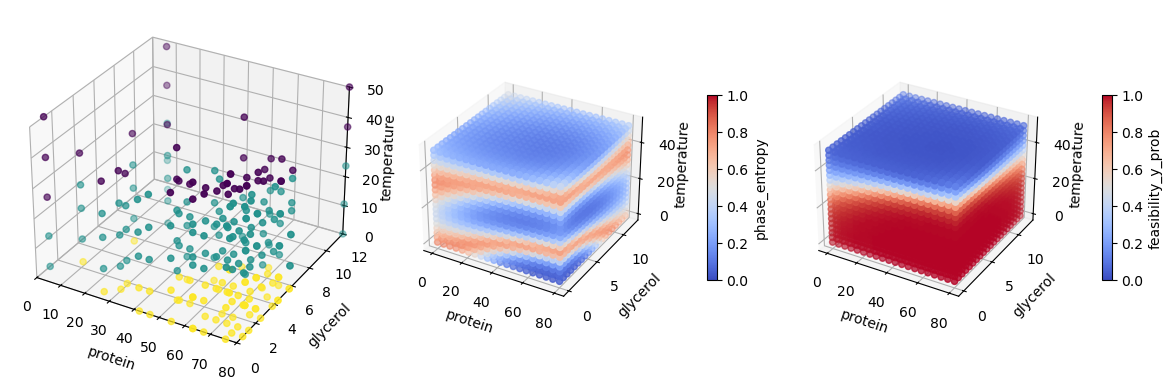

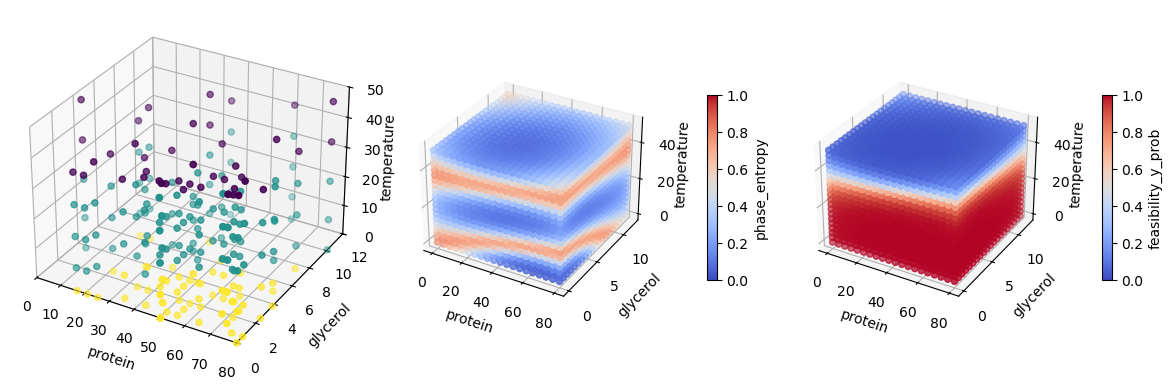

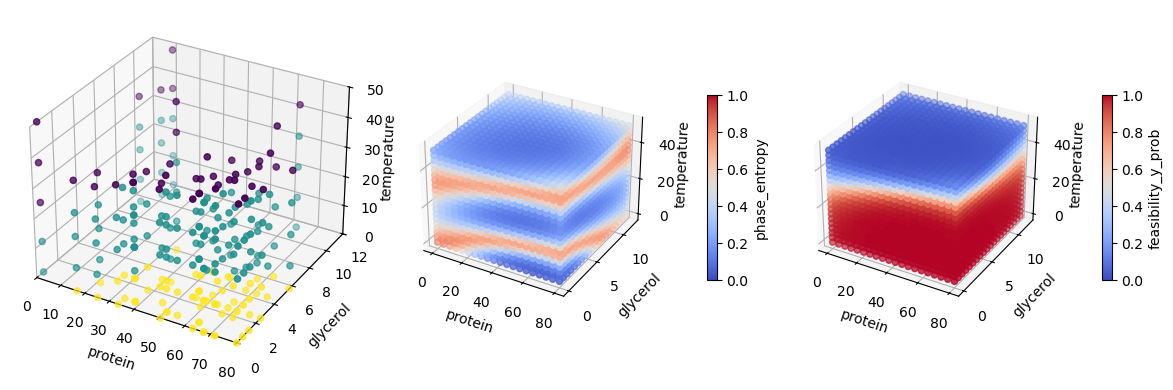

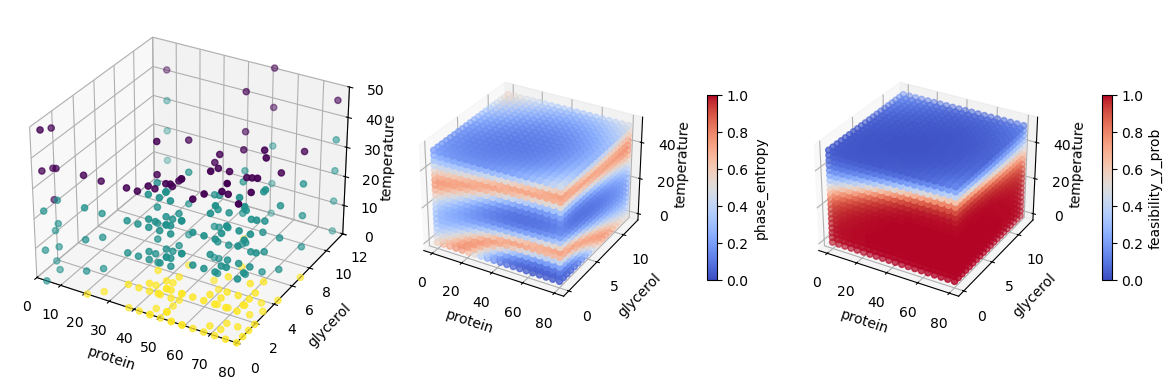

In [33]:
for direc in run_direcs:
    ds_files = get_sorted_nc_files(direc)
    ds = xr.load_dataset(ds_files[-1])
    plot_progress(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
        feasibilty_probability_variable="feasibility_y_prob"
    )
    plt.show()

## Plot Expenses

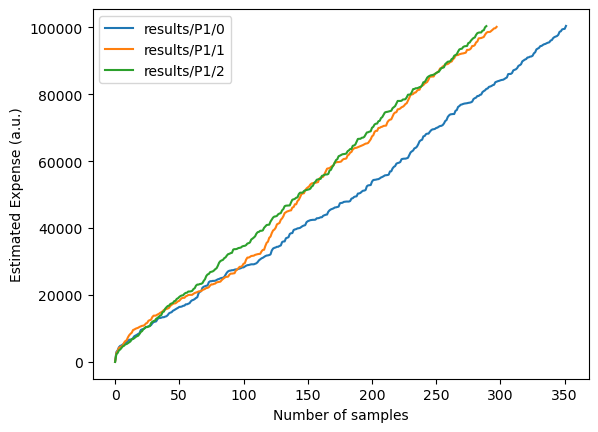

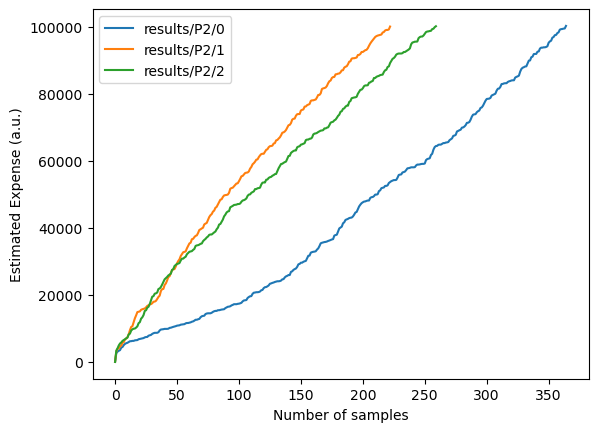

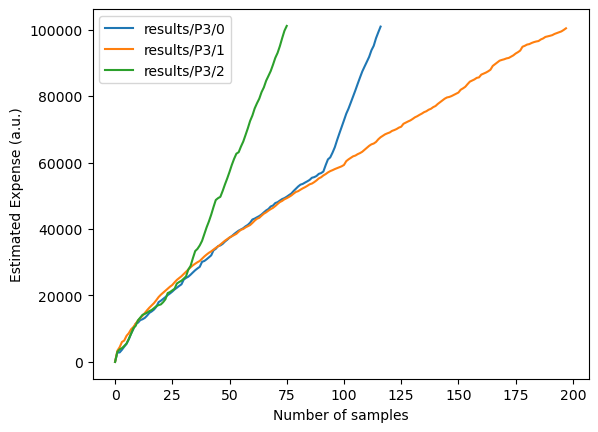

/var/folders/rp/7vyn7s1x0nnbgmjhr2bvs_1c002hph/T/ipykernel_20853/1799458306.py:16: UserWarning: No expense file found for results/P4/0, run may not have finished.
  warnings.warn(f"No expense file found for {direc}, run may not have finished.")


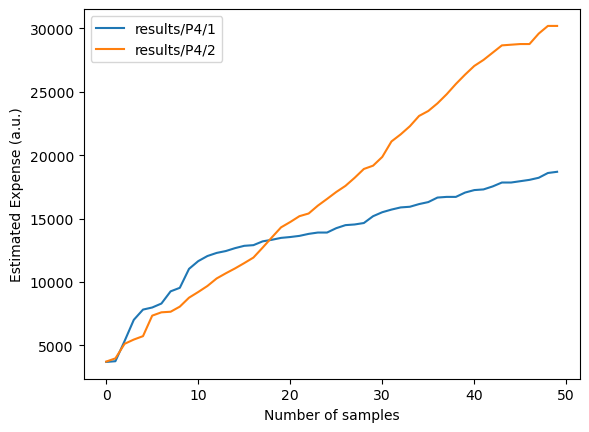

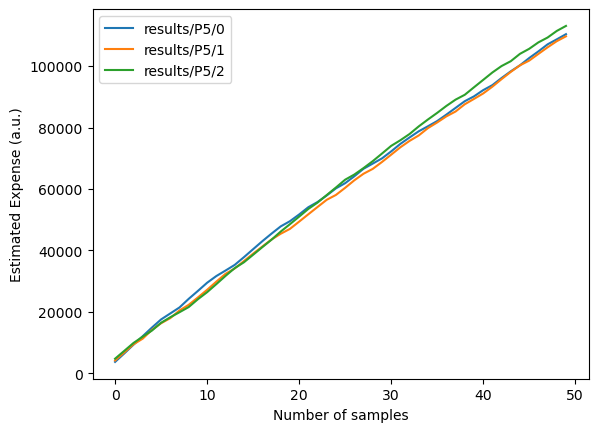

In [34]:
import warnings 
pipeline_direcs = sorted(get_immediate_subdirs(RESULTS_DIR))

for pdirec in pipeline_direcs:
    fig, ax = plt.subplots()
    for j in range(3):
        direc = pdirec+f"/{j}"
        try:
            expense = np.load(direc+"/expense.npy")
            ax.plot(
                np.arange(expense.shape[0]), 
                expense,
                label = f"{direc}"
            )
        except FileNotFoundError:
            warnings.warn(f"No expense file found for {direc}, run may not have finished.")

    if "budget" in RESULTS_DIR:
        import re
        match = re.search(r"results_(.+?)_budget", RESULTS_DIR)
        sci_str = match.group(1)
        float_str = sci_str.replace('p', '.').replace('m', '-')
        ax.axhline(float(float_str), ls='--', color="k")
    ax.set_xlabel("Number of samples")
    ax.set_ylabel("Estimated Expense (a.u.)")
    ax.legend()
    plt.show()